### 🟡 1


=== 기초 암 분류 학습 ===
데이터: 569개 샘플, 30개 특성
악성: 212개, 양성: 357개
정확도: 93.86%
새로운 데이터 예측: 양성
학습 완료!

--------------------------------
적당한 하이파라미터를 골라보자


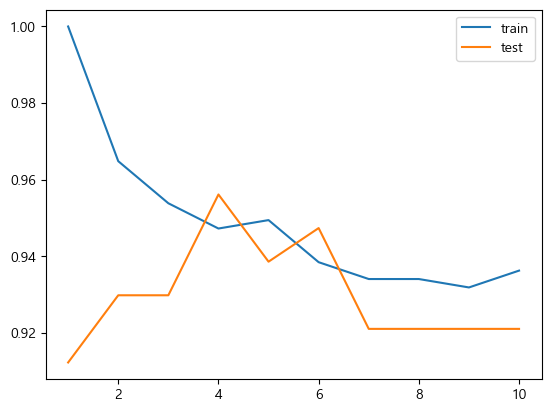

In [6]:
"""
기초 암 분류 - KNN 알고리즘
"""

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("=== 기초 암 분류 학습 ===")

# 1. 데이터 로드
cancer = load_breast_cancer()
X = cancer.data  # 특성 데이터
y = cancer.target  # 타겟 데이터 (0: 악성, 1: 양성)

print(f"데이터: {X.shape[0]}개 샘플, {X.shape[1]}개 특성")
print(f"악성: {sum(y==0)}개, 양성: {sum(y==1)}개")

# 2. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. KNN 모델 만들기
knn = KNeighborsClassifier(n_neighbors=5)

# 4. 모델 훈련 (fit = 훈련(train))
knn.fit(X_train, y_train)

# 5. 예측하기 (predict = 예측(test))
y_pred = knn.predict(X_test)

# 6. 정확도 확인
accuracy = accuracy_score(y_test, y_pred)
print(f"정확도: {accuracy:.2%}")

# 7. 간단한 예측 예시
new_data = X_test[0].reshape(1, -1)
prediction = knn.predict(new_data)[0]
print(f"새로운 데이터 예측: {'악성' if prediction == 0 else '양성'}")

print("학습 완료!") 


# ===================================================
# 적당한 하이파라미터를 골라보자
print("\n--------------------------------")
print("적당한 하이파라미터를 골라보자")
n_neighbors = 10 # 적당히
trainscoreList = list()
testscoreList = list()

for i in range(1, n_neighbors+1):
    model = KNeighborsClassifier(n_neighbors=i)  # 이웃의 개수
    model.fit(X_train, y_train)
    score1 = model.score(X_train, y_train)
    score2 = model.score(X_test, y_test)
    trainscoreList.append(score1)
    testscoreList.append(score2)

import matplotlib.pyplot as plt
# x축, 축
plt.plot(range(1, len(trainscoreList)+1), trainscoreList, label="train")
plt.plot(range(1, len(testscoreList)+1), testscoreList, label="test")
plt.legend()
plt.show()






### 🟡 2


암 분류 머신러닝 프로젝트 시작!
=== 1. 데이터 로드 및 탐색 ===
데이터셋 정보:
샘플 수: 569
특성 수: 30
클래스 분포:
target
1    357
0    212
Name: count, dtype: int64

클래스 의미:
0: 악성 종양 (Malignant)
1: 양성 종양 (Benign)

데이터 기본 통계:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799       

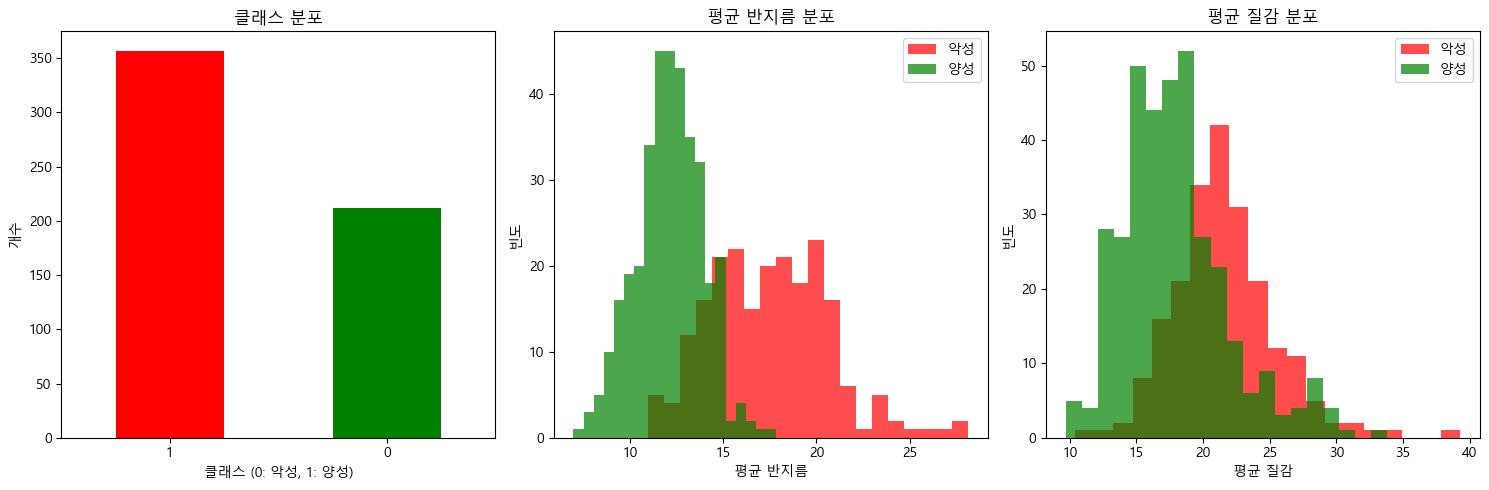

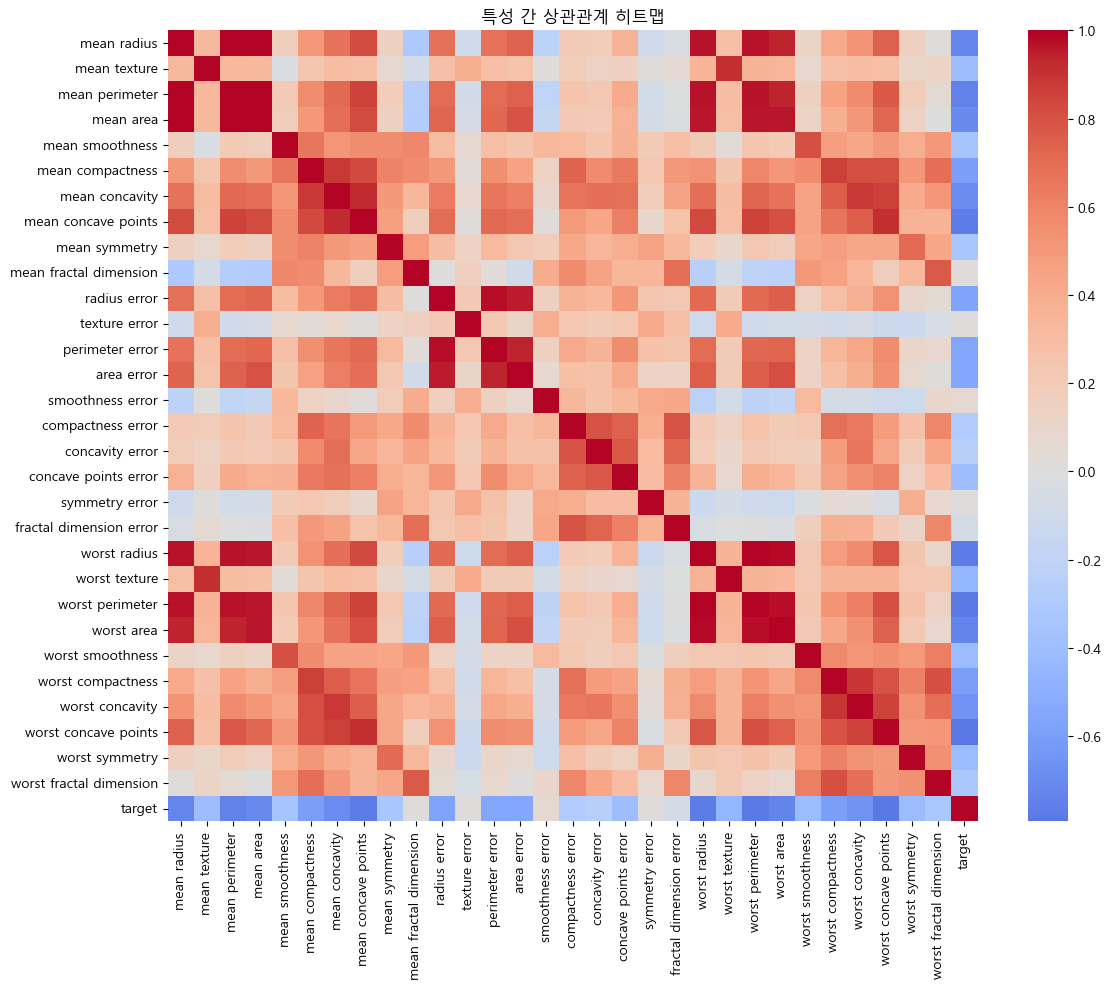

타겟과의 상관관계 (상위 10개):
target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
Name: target, dtype: float64

=== 3. 데이터 전처리 ===
훈련 데이터 크기: (455, 30)
테스트 데이터 크기: (114, 30)
훈련 데이터 클래스 분포:
target
1    285
0    170
Name: count, dtype: int64
테스트 데이터 클래스 분포:
target
1    72
0    42
Name: count, dtype: int64

스케일링 완료!
훈련 데이터 평균: -0.000000
훈련 데이터 표준편차: 1.000000

=== 4. 다양한 머신러닝 모델 훈련 및 평가 ===

=== KNN 모델 훈련 중 ===
정확도: 0.9561
교차 검증 평균: 0.9670 (+/- 0.0417)

분류 보고서:
              precision    recall  f1-score   support

          악성       0.95      0.93      0.94        42
          양성       0.96      0.97      0.97        72

    accuracy                           0

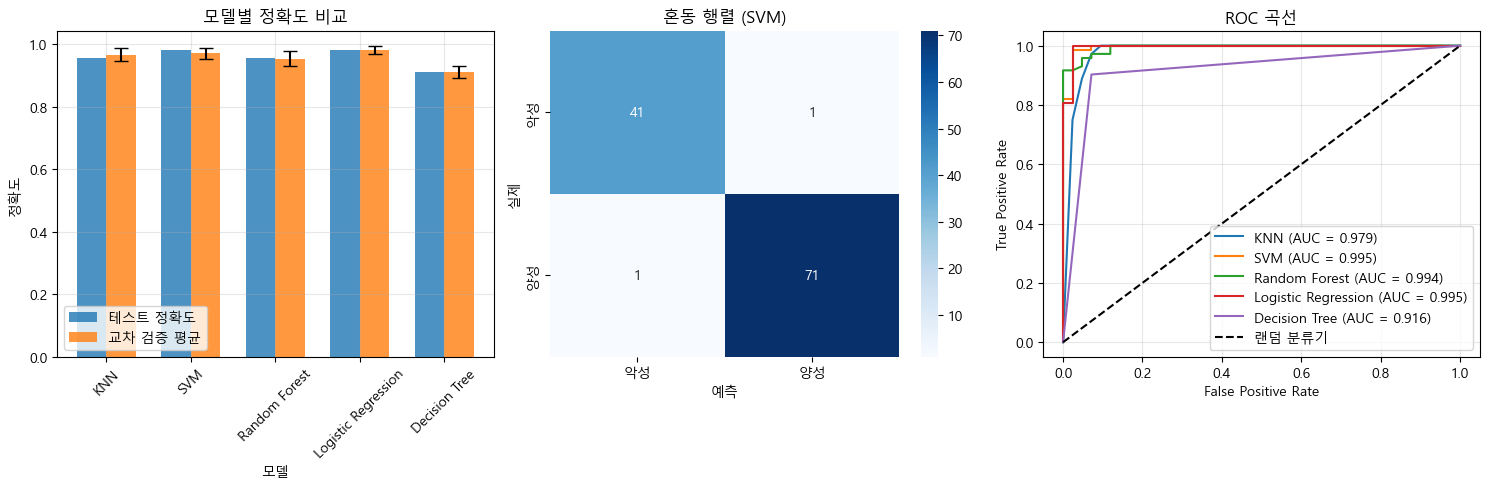


=== 6. 하이퍼파라미터 튜닝 ===
=== KNN 하이퍼파라미터 튜닝 ===
최적 파라미터: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
최적 교차 검증 점수: 0.9692
튜닝된 모델 테스트 정확도: 0.9825

튜닝된 모델 분류 보고서:
              precision    recall  f1-score   support

          악성       1.00      0.95      0.98        42
          양성       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


=== 7. 특성 중요도 분석 ===


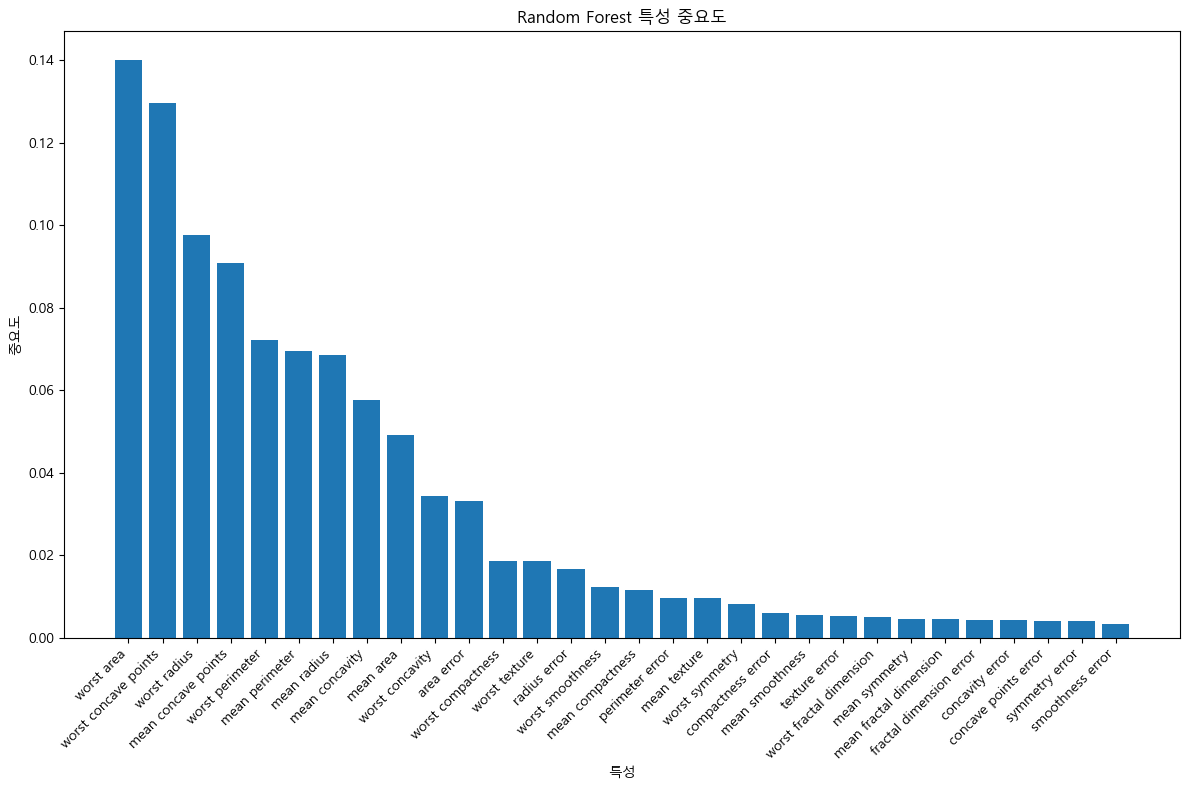

상위 10개 중요한 특성:
 1. worst area: 0.1400
 2. worst concave points: 0.1295
 3. worst radius: 0.0977
 4. mean concave points: 0.0909
 5. worst perimeter: 0.0722
 6. mean perimeter: 0.0696
 7. mean radius: 0.0687
 8. mean concavity: 0.0576
 9. mean area: 0.0492
10. worst concavity: 0.0343

=== 8. 모델 저장 및 예측 ===
모델과 스케일러가 저장되었습니다!
- cancer_classification_model.pkl
- cancer_scaler.pkl

새로운 데이터 예측 예시:
실제 레이블: 1 (양성)
예측 레이블: 1 (양성)
악성 확률: 0.0000
양성 확률: 1.0000
예측 정확: 맞음

=== 9. 결론 및 요약 ===
=== 암 분류 머신러닝 프로젝트 결과 요약 ===

1. 데이터셋 정보:
   - 총 샘플 수: 569
   - 특성 수: 30
   - 클래스 분포: 악성 212개, 양성 357개

2. 모델 성능 비교:
   - KNN: 0.9561 (교차검증: 0.9670)
   - SVM: 0.9825 (교차검증: 0.9714)
   - Random Forest: 0.9561 (교차검증: 0.9538)
   - Logistic Regression: 0.9825 (교차검증: 0.9802)
   - Decision Tree: 0.9123 (교차검증: 0.9099)

3. 최고 성능 모델: SVM
   - 정확도: 0.9825

4. 하이퍼파라미터 튜닝 후 KNN 성능:
   - 튜닝된 정확도: 0.9825

5. 주요 특성 (상위 5개):
   - worst area
   - worst concave points
   - worst radius
   - mean concave points
   - worst perimet

In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
암 분류 머신러닝 프로젝트
유방암 데이터셋을 사용하여 악성(malignant)과 양성(benign) 종양을 분류
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def load_and_explore_data():
    """데이터 로드 및 탐색"""
    print("=== 1. 데이터 로드 및 탐색 ===")
    
    # 유방암 데이터셋 로드
    cancer = load_breast_cancer()
    X = cancer.data
    y = cancer.target
    
    # 데이터프레임으로 변환
    df = pd.DataFrame(X, columns=cancer.feature_names)
    df['target'] = y
    
    print(f"데이터셋 정보:")
    print(f"샘플 수: {X.shape[0]}")
    print(f"특성 수: {X.shape[1]}")
    print(f"클래스 분포:\n{df['target'].value_counts()}")
    print("\n클래스 의미:")
    print("0: 악성 종양 (Malignant)")
    print("1: 양성 종양 (Benign)")
    
    # 데이터 기본 통계
    print("\n데이터 기본 통계:")
    print(df.describe())
    
    # 결측값 확인
    print("\n결측값 확인:")
    print(df.isnull().sum())
    
    return df, cancer

def visualize_data(df):
    """데이터 시각화"""
    print("\n=== 2. 데이터 시각화 ===")
    
    # 클래스 분포 시각화
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    df['target'].value_counts().plot(kind='bar', color=['red', 'green'])
    plt.title('클래스 분포')
    plt.xlabel('클래스 (0: 악성, 1: 양성)')
    plt.ylabel('개수')
    plt.xticks(rotation=0)
    
    # 주요 특성들의 분포
    plt.subplot(1, 3, 2)
    plt.hist(df[df['target']==0]['mean radius'], alpha=0.7, label='악성', color='red', bins=20)
    plt.hist(df[df['target']==1]['mean radius'], alpha=0.7, label='양성', color='green', bins=20)
    plt.title('평균 반지름 분포')
    plt.xlabel('평균 반지름')
    plt.ylabel('빈도')
    plt.legend()
    
    plt.subplot(1, 3, 3)
    plt.hist(df[df['target']==0]['mean texture'], alpha=0.7, label='악성', color='red', bins=20)
    plt.hist(df[df['target']==1]['mean texture'], alpha=0.7, label='양성', color='green', bins=20)
    plt.title('평균 질감 분포')
    plt.xlabel('평균 질감')
    plt.ylabel('빈도')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 상관관계 히트맵
    plt.figure(figsize=(12, 10))
    correlation_matrix = df.corr()
    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
    plt.title('특성 간 상관관계 히트맵')
    plt.tight_layout()
    plt.show()
    
    # 타겟과의 상관관계
    target_corr = correlation_matrix['target'].sort_values(ascending=False)
    print("타겟과의 상관관계 (상위 10개):")
    print(target_corr.head(11))  # target 자신 제외하고 10개

def preprocess_data(df):
    """데이터 전처리"""
    print("\n=== 3. 데이터 전처리 ===")
    
    # 특성과 타겟 분리
    X = df.drop('target', axis=1)
    y = df['target']
    
    # 훈련/테스트 데이터 분할
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    print(f"훈련 데이터 크기: {X_train.shape}")
    print(f"테스트 데이터 크기: {X_test.shape}")
    print(f"훈련 데이터 클래스 분포:\n{y_train.value_counts()}")
    print(f"테스트 데이터 클래스 분포:\n{y_test.value_counts()}")
    
    # 특성 스케일링
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("\n스케일링 완료!")
    print(f"훈련 데이터 평균: {X_train_scaled.mean():.6f}")
    print(f"훈련 데이터 표준편차: {X_train_scaled.std():.6f}")
    
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

def train_and_evaluate_models(X_train_scaled, X_test_scaled, y_train, y_test):
    """다양한 머신러닝 모델 훈련 및 평가"""
    print("\n=== 4. 다양한 머신러닝 모델 훈련 및 평가 ===")
    
    # 모델들을 딕셔너리로 정의
    models = {
        'KNN': KNeighborsClassifier(),
        'SVM': SVC(probability=True),
        'Random Forest': RandomForestClassifier(random_state=42),
        'Logistic Regression': LogisticRegression(random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42)
    }
    
    # 결과를 저장할 딕셔너리
    results = {}
    
    # 각 모델 훈련 및 평가
    for name, model in models.items():
        print(f"\n=== {name} 모델 훈련 중 ===")
        
        # 모델 훈련
        model.fit(X_train_scaled, y_train)
        
        # 예측
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
        
        # 성능 평가
        accuracy = accuracy_score(y_test, y_pred)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
        
        # 결과 저장
        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba
        }
        
        print(f"정확도: {accuracy:.4f}")
        print(f"교차 검증 평균: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
        
        # 분류 보고서
        print("\n분류 보고서:")
        print(classification_report(y_test, y_pred, target_names=['악성', '양성']))
    
    return results

def visualize_results(results, y_test):
    """결과 시각화"""
    print("\n=== 5. 결과 시각화 ===")
    
    plt.figure(figsize=(15, 5))
    
    # 정확도 비교
    plt.subplot(1, 3, 1)
    model_names = list(results.keys())
    accuracies = [results[name]['accuracy'] for name in model_names]
    cv_means = [results[name]['cv_mean'] for name in model_names]
    cv_stds = [results[name]['cv_std'] for name in model_names]
    
    x = np.arange(len(model_names))
    width = 0.35
    
    plt.bar(x - width/2, accuracies, width, label='테스트 정확도', alpha=0.8)
    plt.bar(x + width/2, cv_means, width, label='교차 검증 평균', alpha=0.8)
    plt.errorbar(x + width/2, cv_means, yerr=cv_stds, fmt='none', color='black', capsize=5)
    
    plt.xlabel('모델')
    plt.ylabel('정확도')
    plt.title('모델별 정확도 비교')
    plt.xticks(x, model_names, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 혼동 행렬
    plt.subplot(1, 3, 2)
    best_model_name = max(results.keys(), key=lambda x: results[x]['accuracy'])
    best_model = results[best_model_name]['model']
    y_pred_best = results[best_model_name]['y_pred']
    
    cm = confusion_matrix(y_test, y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['악성', '양성'], 
                yticklabels=['악성', '양성'])
    plt.title(f'혼동 행렬 ({best_model_name})')
    plt.ylabel('실제')
    plt.xlabel('예측')
    
    # ROC 곡선 (가능한 경우)
    plt.subplot(1, 3, 3)
    for name, result in results.items():
        if result['y_pred_proba'] is not None:
            fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
            auc = roc_auc_score(y_test, result['y_pred_proba'])
            plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', label='랜덤 분류기')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC 곡선')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return best_model_name

def hyperparameter_tuning(X_train_scaled, X_test_scaled, y_train, y_test):
    """하이퍼파라미터 튜닝"""
    print("\n=== 6. 하이퍼파라미터 튜닝 ===")
    
    # KNN 하이퍼파라미터 튜닝
    print("=== KNN 하이퍼파라미터 튜닝 ===")
    knn_param_grid = {
        'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
    
    knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    knn_grid.fit(X_train_scaled, y_train)
    
    print(f"최적 파라미터: {knn_grid.best_params_}")
    print(f"최적 교차 검증 점수: {knn_grid.best_score_:.4f}")
    
    # 튜닝된 모델로 예측
    y_pred_tuned = knn_grid.predict(X_test_scaled)
    accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
    print(f"튜닝된 모델 테스트 정확도: {accuracy_tuned:.4f}")
    
    print("\n튜닝된 모델 분류 보고서:")
    print(classification_report(y_test, y_pred_tuned, target_names=['악성', '양성']))
    
    return knn_grid

def feature_importance_analysis(results, cancer):
    """특성 중요도 분석"""
    print("\n=== 7. 특성 중요도 분석 ===")
    
    # Random Forest 특성 중요도
    rf_model = results['Random Forest']['model']
    feature_importance = rf_model.feature_importances_
    feature_names = cancer.feature_names
    
    # 특성 중요도 시각화
    plt.figure(figsize=(12, 8))
    indices = np.argsort(feature_importance)[::-1]
    
    plt.bar(range(len(feature_importance)), feature_importance[indices])
    plt.xticks(range(len(feature_importance)), [feature_names[i] for i in indices], rotation=45, ha='right')
    plt.title('Random Forest 특성 중요도')
    plt.xlabel('특성')
    plt.ylabel('중요도')
    plt.tight_layout()
    plt.show()
    
    # 상위 10개 특성 출력
    print("상위 10개 중요한 특성:")
    for i in range(10):
        print(f"{i+1:2d}. {feature_names[indices[i]]}: {feature_importance[indices[i]]:.4f}")
    
    return indices, feature_names

def save_model_and_predict(best_model, scaler, X_test, y_test):
    """모델 저장 및 예측"""
    print("\n=== 8. 모델 저장 및 예측 ===")
    
    import joblib
    
    # 모델 저장
    joblib.dump(best_model, 'cancer_classification_model.pkl')
    joblib.dump(scaler, 'cancer_scaler.pkl')
    
    print("모델과 스케일러가 저장되었습니다!")
    print("- cancer_classification_model.pkl")
    print("- cancer_scaler.pkl")
    
    # 새로운 데이터로 예측하는 함수
    def predict_cancer(new_data):
        """
        새로운 데이터로 암 분류 예측
        
        Parameters:
        new_data: numpy array or list (30개 특성)
        
        Returns:
        prediction: 0 (악성) 또는 1 (양성)
        probability: 예측 확률
        """
        # 데이터 형태 변환
        if isinstance(new_data, list):
            new_data = np.array(new_data).reshape(1, -1)
        elif new_data.ndim == 1:
            new_data = new_data.reshape(1, -1)
        
        # 스케일링
        new_data_scaled = scaler.transform(new_data)
        
        # 예측
        prediction = best_model.predict(new_data_scaled)[0]
        probability = best_model.predict_proba(new_data_scaled)[0]
        
        return prediction, probability
    
    # 예시: 테스트 데이터의 첫 번째 샘플로 예측
    sample_data = X_test.iloc[0].values
    actual_label = y_test.iloc[0]
    
    prediction, probability = predict_cancer(sample_data)
    
    print("\n새로운 데이터 예측 예시:")
    print(f"실제 레이블: {actual_label} ({'악성' if actual_label == 0 else '양성'})")
    print(f"예측 레이블: {prediction} ({'악성' if prediction == 0 else '양성'})")
    print(f"악성 확률: {probability[0]:.4f}")
    print(f"양성 확률: {probability[1]:.4f}")
    print(f"예측 정확: {'맞음' if prediction == actual_label else '틀림'}")
    
    return predict_cancer

def print_summary(results, best_model_name, accuracy_tuned, indices, feature_names, X, y):
    """결론 및 요약"""
    print("\n=== 9. 결론 및 요약 ===")
    
    print("=== 암 분류 머신러닝 프로젝트 결과 요약 ===\n")
    
    print("1. 데이터셋 정보:")
    print(f"   - 총 샘플 수: {X.shape[0]}")
    print(f"   - 특성 수: {X.shape[1]}")
    print(f"   - 클래스 분포: 악성 {sum(y==0)}개, 양성 {sum(y==1)}개\n")
    
    print("2. 모델 성능 비교:")
    for name, result in results.items():
        print(f"   - {name}: {result['accuracy']:.4f} (교차검증: {result['cv_mean']:.4f})")
    
    print(f"\n3. 최고 성능 모델: {best_model_name}")
    print(f"   - 정확도: {results[best_model_name]['accuracy']:.4f}")
    
    print(f"\n4. 하이퍼파라미터 튜닝 후 KNN 성능:")
    print(f"   - 튜닝된 정확도: {accuracy_tuned:.4f}")
    
    print("\n5. 주요 특성 (상위 5개):")
    for i in range(5):
        print(f"   - {feature_names[indices[i]]}")
    
    print("\n6. 프로젝트 완료!")
    print("   - 모델이 저장되었습니다.")
    print("   - 새로운 데이터로 예측할 수 있습니다.")

def main():
    """메인 함수"""
    print("암 분류 머신러닝 프로젝트 시작!")
    print("=" * 50)
    
    # 1. 데이터 로드 및 탐색
    df, cancer = load_and_explore_data()
    
    # 2. 데이터 시각화
    visualize_data(df)
    
    # 3. 데이터 전처리
    X_train_scaled, X_test_scaled, y_train, y_test, scaler = preprocess_data(df)
    
    # 4. 모델 훈련 및 평가
    results = train_and_evaluate_models(X_train_scaled, X_test_scaled, y_train, y_test)
    
    # 5. 결과 시각화
    best_model_name = visualize_results(results, y_test)
    
    # 6. 하이퍼파라미터 튜닝
    knn_grid = hyperparameter_tuning(X_train_scaled, X_test_scaled, y_train, y_test)
    accuracy_tuned = accuracy_score(y_test, knn_grid.predict(X_test_scaled))
    
    # 7. 특성 중요도 분석
    indices, feature_names = feature_importance_analysis(results, cancer)
    
    # 8. 모델 저장 및 예측
    X_test_df = df.drop('target', axis=1).iloc[len(X_train_scaled):].reset_index(drop=True)
    y_test_series = df['target'].iloc[len(X_train_scaled):].reset_index(drop=True)
    predict_cancer = save_model_and_predict(knn_grid.best_estimator_, scaler, X_test_df, y_test_series)
    
    # 9. 요약
    print_summary(results, best_model_name, accuracy_tuned, indices, feature_names, 
                  df.drop('target', axis=1), df['target'])
    
    print("\n프로젝트가 성공적으로 완료되었습니다!")

if __name__ == "__main__":
    main() 